# Enhanced PPO vs DQN Solaris Comparison

Comprehensive analysis comparing PPO and DQN agents on the Solaris environment.
Metrics: Sample Efficiency, Final Performance, Training Stability, and Learning Dynamics

In [1]:
import csv
import json
import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# Locate data root
cwd = Path.cwd()
root = cwd
while not (root / 'time_series').exists() and root != root.parent:
    root = root.parent
if not (root / 'time_series').exists():
    raise FileNotFoundError('Could not locate time_series directory')

DATA_ROOT = root / 'time_series'
OUTPUT_DIR = cwd / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data root: {DATA_ROOT}')
print(f'Output dir: {OUTPUT_DIR}')

Data root: /home/vydi/ML Challenges/challenge3__<5>/time_series
Output dir: /home/vydi/ML Challenges/challenge3__<5>/variance_analysis/figures


In [2]:
# Utility functions
def load_csv_series(csv_path):
    """Load Step and Value columns from CSV"""
    steps, values = [], []
    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            steps.append(float(row['Step']))
            values.append(float(row['Value']))
    return np.array(steps, dtype=float), np.array(values, dtype=float)

def load_replicates_from_dir(root_dir):
    """Load all CSV replicates from a directory"""
    replicates = {}
    if not root_dir.exists():
        return replicates
    for path in sorted(root_dir.glob('*.csv')):
        name = path.stem
        steps, values = load_csv_series(path)
        replicates[name] = {'path': path, 'steps': steps, 'values': values}
    return replicates

def auc_normalized(steps, values):
    """Compute AUC normalized by total step range"""
    if len(steps) < 2:
        return 0.0
    area = trapezoid(values, steps)
    total = steps[-1] - steps[0] if steps[-1] > steps[0] else 1.0
    return area / total

def threshold_step(steps, values, threshold):
    """Find step at which value first reaches threshold"""
    for s, v in zip(steps, values):
        if v >= threshold:
            return s
    return math.inf

print('Utility functions loaded')

Utility functions loaded


In [3]:
# Load DQN data (reward mean, loss, episode length mean)
dqn_rew_reps = load_replicates_from_dir(DATA_ROOT / 'dqn' / 'rew_mean')
dqn_loss_reps = load_replicates_from_dir(DATA_ROOT / 'dqn' / 'loss')
dqn_len_reps = load_replicates_from_dir(DATA_ROOT / 'dqn' / 'len_mean')

# Load PPO data (mean return, policy loss, value loss)
ppo_ret_reps = load_replicates_from_dir(DATA_ROOT / 'ppo' / 'mean_return')
ppo_ploss_reps = load_replicates_from_dir(DATA_ROOT / 'ppo' / 'policy_loss')
ppo_vloss_reps = load_replicates_from_dir(DATA_ROOT / 'ppo' / 'value_loss')

print(f'Loaded {len(dqn_rew_reps)} DQN reward replicates')
print(f'Loaded {len(dqn_loss_reps)} DQN loss replicates')
print(f'Loaded {len(dqn_len_reps)} DQN len_mean replicates')
print(f'Loaded {len(ppo_ret_reps)} PPO return replicates')
print(f'Loaded {len(ppo_ploss_reps)} PPO policy_loss replicates')
print(f'Loaded {len(ppo_vloss_reps)} PPO value_loss replicates')

Loaded 3 DQN reward replicates
Loaded 3 DQN loss replicates
Loaded 3 DQN len_mean replicates
Loaded 3 PPO return replicates
Loaded 3 PPO policy_loss replicates
Loaded 3 PPO value_loss replicates


In [4]:
# Compute metrics for DQN and PPO
def compute_metrics(rew_reps, loss_reps=None, len_reps=None, agent_name='Agent'):
    """Compute final performance, stability, and sample efficiency metrics"""
    final_values = [rep['values'][-1] for rep in rew_reps.values()]
    mean_final = float(np.mean(final_values))
    std_final = float(np.std(final_values, ddof=1)) if len(final_values) > 1 else 0.0
    
    # Training stability via AUC
    aucs = [auc_normalized(rep['steps'], rep['values']) for rep in rew_reps.values()]
    stability = float(np.mean(aucs))
    
    # Sample efficiency: steps to reach 95% of final mean
    threshold = mean_final * 0.95
    sample_eff = [threshold_step(rep['steps'], rep['values'], threshold) for rep in rew_reps.values()]
    sample_eff_mean = float(np.mean([x for x in sample_eff if x != math.inf]) if any(x != math.inf for x in sample_eff) else 0.0)
    
    metrics = {
        'agent': agent_name,
        'final_performance_mean': mean_final,
        'final_performance_std': std_final,
        'training_stability_auc': stability,
        'sample_efficiency_steps': sample_eff_mean,
    }
    
    # Add average loss if provided
    if loss_reps:
        loss_values = [rep['values'][-1] for rep in loss_reps.values()]
        metrics['avg_loss_final'] = float(np.mean(loss_values))
    
    # Add average episode length if provided
    if len_reps:
        len_values = [rep['values'][-1] for rep in len_reps.values()]
        metrics['avg_episode_length_final'] = float(np.mean(len_values))
    
    return metrics

dqn_metrics = compute_metrics(dqn_rew_reps, dqn_loss_reps, dqn_len_reps, 'DQN')
ppo_metrics = compute_metrics(ppo_ret_reps, ppo_ploss_reps, ppo_vloss_reps, 'PPO')

print('\n=== DQN Metrics ===')
for key, val in dqn_metrics.items():
    if isinstance(val, float):
        print(f'{key}: {val:.4f}')
    else:
        print(f'{key}: {val}')

print('\n=== PPO Metrics ===')
for key, val in ppo_metrics.items():
    if isinstance(val, float):
        print(f'{key}: {val:.4f}')
    else:
        print(f'{key}: {val}')


=== DQN Metrics ===
agent: DQN
final_performance_mean: 1301.2000
final_performance_std: 163.1059
training_stability_auc: 1332.7612
sample_efficiency_steps: 2921.6667
avg_loss_final: 0.0031
avg_episode_length_final: 8589.1732

=== PPO Metrics ===
agent: PPO
final_performance_mean: 3535.3333
final_performance_std: 1826.8665
training_stability_auc: 2700.6358
sample_efficiency_steps: 426666.6667
avg_loss_final: 0.0008
avg_episode_length_final: 2534.0792


Saved /home/vydi/ML Challenges/challenge3__<5>/variance_analysis/figures/learning_curves_rewards.png


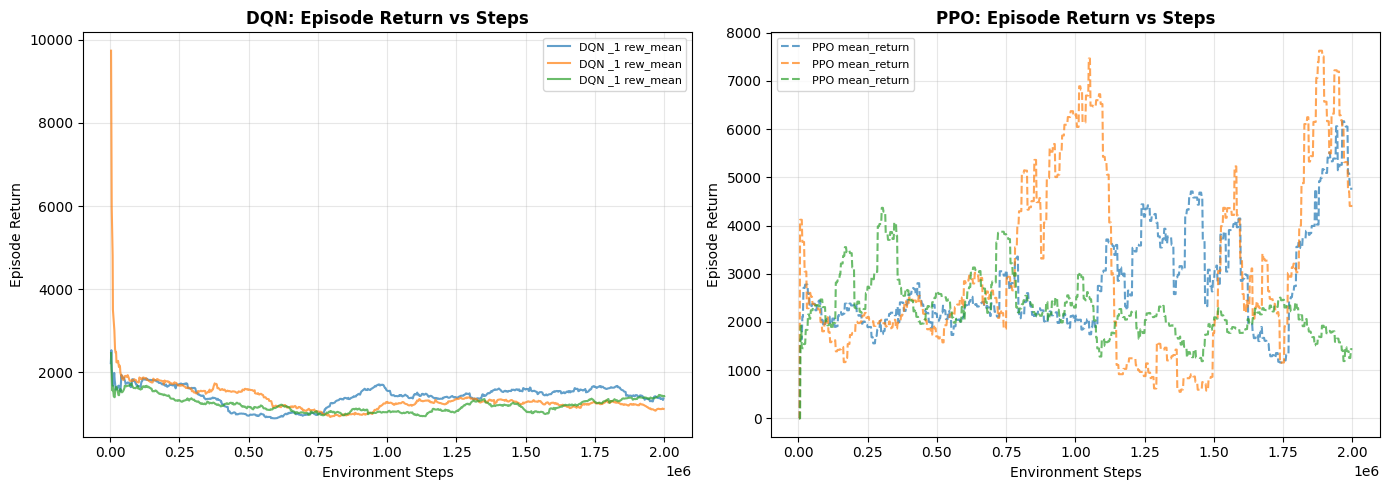

In [5]:
# Figure 1: Learning Curves (Reward/Return)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, rep in sorted(dqn_rew_reps.items()):
    plt.plot(rep['steps'], rep['values'], label=f'DQN {name[-11:]}', alpha=0.7, linewidth=1.5)
plt.title('DQN: Episode Return vs Steps', fontsize=12, fontweight='bold')
plt.xlabel('Environment Steps')
plt.ylabel('Episode Return')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, rep in sorted(ppo_ret_reps.items()):
    plt.plot(rep['steps'], rep['values'], label=f'PPO {name[-11:]}', alpha=0.7, linewidth=1.5, linestyle='--')
plt.title('PPO: Episode Return vs Steps', fontsize=12, fontweight='bold')
plt.xlabel('Environment Steps')
plt.ylabel('Episode Return')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = OUTPUT_DIR / 'learning_curves_rewards.png'
plt.savefig(fig_path, dpi=200)
print(f'Saved {fig_path}')
plt.show()

Saved /home/vydi/ML Challenges/challenge3__<5>/variance_analysis/figures/loss_curves.png


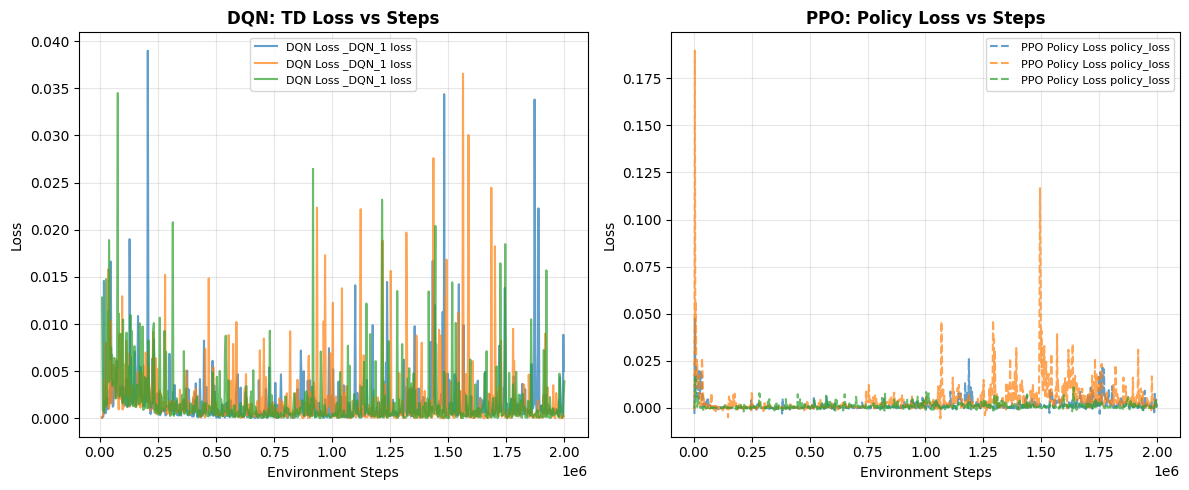

In [6]:
# Figure 2: Loss Curves (DQN Loss)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, rep in sorted(dqn_loss_reps.items()):
    plt.plot(rep['steps'], rep['values'], label=f'DQN Loss {name[-11:]}', alpha=0.7, linewidth=1.5)
plt.title('DQN: TD Loss vs Steps', fontsize=12, fontweight='bold')
plt.xlabel('Environment Steps')
plt.ylabel('Loss')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

# PPO Policy Loss
plt.subplot(1, 2, 2)
for name, rep in sorted(ppo_ploss_reps.items()):
    plt.plot(rep['steps'], rep['values'], label=f'PPO Policy Loss {name[-11:]}', alpha=0.7, linewidth=1.5, linestyle='--')
plt.title('PPO: Policy Loss vs Steps', fontsize=12, fontweight='bold')
plt.xlabel('Environment Steps')
plt.ylabel('Loss')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = OUTPUT_DIR / 'loss_curves.png'
plt.savefig(fig_path, dpi=200)
print(f'Saved {fig_path}')
plt.show()

Saved /home/vydi/ML Challenges/challenge3__<5>/variance_analysis/figures/ppo_value_loss.png


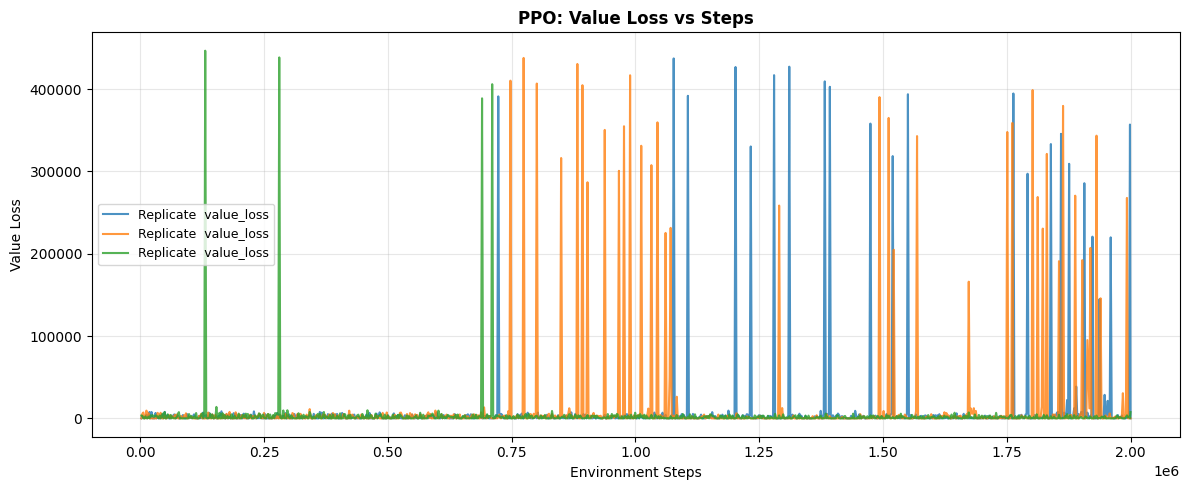

In [7]:
# Figure 3: PPO Value Loss
plt.figure(figsize=(12, 5))

for name, rep in sorted(ppo_vloss_reps.items()):
    plt.plot(rep['steps'], rep['values'], label=f'Replicate {name[-11:]}', alpha=0.8, linewidth=1.5)

plt.title('PPO: Value Loss vs Steps', fontsize=12, fontweight='bold')
plt.xlabel('Environment Steps')
plt.ylabel('Value Loss')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig_path = OUTPUT_DIR / 'ppo_value_loss.png'
plt.savefig(fig_path, dpi=200)
print(f'Saved {fig_path}')
plt.show()

Saved /home/vydi/ML Challenges/challenge3__<5>/variance_analysis/figures/dqn_episode_length.png


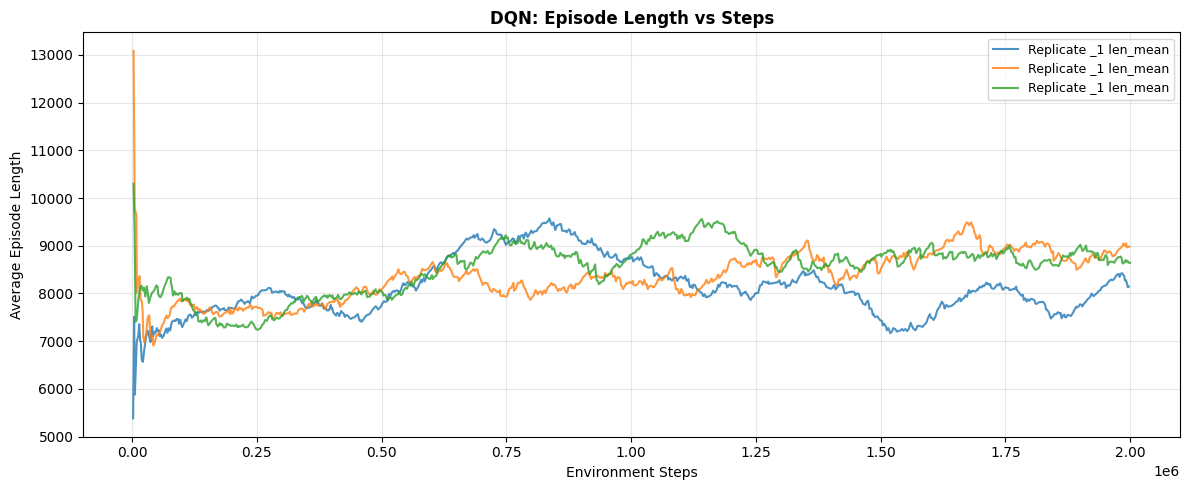

In [8]:
# Figure 4: Episode Length Comparison (DQN only)
plt.figure(figsize=(12, 5))

for name, rep in sorted(dqn_len_reps.items()):
    plt.plot(rep['steps'], rep['values'], label=f'Replicate {name[-11:]}', alpha=0.8, linewidth=1.5)

plt.title('DQN: Episode Length vs Steps', fontsize=12, fontweight='bold')
plt.xlabel('Environment Steps')
plt.ylabel('Average Episode Length')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig_path = OUTPUT_DIR / 'dqn_episode_length.png'
plt.savefig(fig_path, dpi=200)
print(f'Saved {fig_path}')
plt.show()

Saved /home/vydi/ML Challenges/challenge3__<5>/variance_analysis/figures/metrics_comparison.png


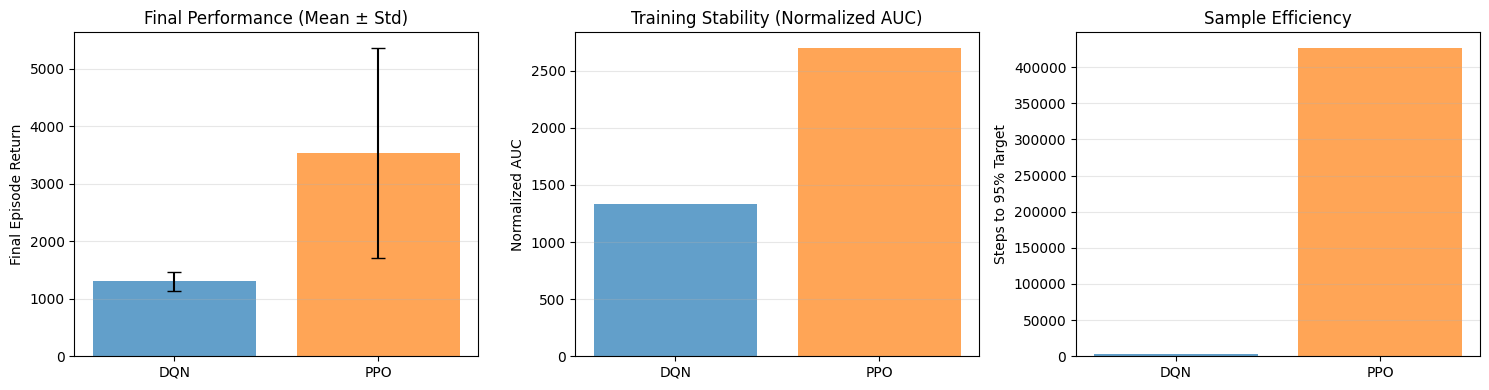

In [9]:
# Figure 5: Metrics Comparison Bar Charts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

agents = ['DQN', 'PPO']
final_perf = [dqn_metrics['final_performance_mean'], ppo_metrics['final_performance_mean']]
final_std = [dqn_metrics['final_performance_std'], ppo_metrics['final_performance_std']]
stability = [dqn_metrics['training_stability_auc'], ppo_metrics['training_stability_auc']]
sample_eff = [dqn_metrics['sample_efficiency_steps'], ppo_metrics['sample_efficiency_steps']]

# Final Performance
axes[0].bar(agents, final_perf, color=['#1f77b4', '#ff7f0e'], alpha=0.7)
axes[0].errorbar(agents, final_perf, yerr=final_std, fmt='none', color='black', capsize=5)
axes[0].set_ylabel('Final Episode Return')
axes[0].set_title('Final Performance (Mean ± Std)')
axes[0].grid(True, alpha=0.3, axis='y')

# Training Stability
axes[1].bar(agents, stability, color=['#1f77b4', '#ff7f0e'], alpha=0.7)
axes[1].set_ylabel('Normalized AUC')
axes[1].set_title('Training Stability (Normalized AUC)')
axes[1].grid(True, alpha=0.3, axis='y')

# Sample Efficiency
axes[2].bar(agents, sample_eff, color=['#1f77b4', '#ff7f0e'], alpha=0.7)
axes[2].set_ylabel('Steps to 95% Target')
axes[2].set_title('Sample Efficiency')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig_path = OUTPUT_DIR / 'metrics_comparison.png'
plt.savefig(fig_path, dpi=200)
print(f'Saved {fig_path}')
plt.show()

In [10]:
# Save results to JSON
all_results = {
    'timestamp': str(Path.cwd()),
    'dqn': dqn_metrics,
    'ppo': ppo_metrics,
    'comparison': {
        'dqn_better_performance': dqn_metrics['final_performance_mean'] > ppo_metrics['final_performance_mean'],
        'dqn_better_stability': dqn_metrics['training_stability_auc'] > ppo_metrics['training_stability_auc'],
        'dqn_better_sample_efficiency': dqn_metrics['sample_efficiency_steps'] < ppo_metrics['sample_efficiency_steps'],
    }
}

metrics_file = cwd / 'ppo_vs_dqn_full_metrics.json'
with open(metrics_file, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f'Saved metrics to {metrics_file}')

# Save summary CSV
csv_file = cwd / 'ppo_vs_dqn_summary.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Metric', 'DQN', 'PPO'])
    writer.writerow(['Final Performance (Mean)', dqn_metrics['final_performance_mean'], ppo_metrics['final_performance_mean']])
    writer.writerow(['Final Performance (Std)', dqn_metrics['final_performance_std'], ppo_metrics['final_performance_std']])
    writer.writerow(['Training Stability (AUC)', dqn_metrics['training_stability_auc'], ppo_metrics['training_stability_auc']])
    writer.writerow(['Sample Efficiency (Steps)', dqn_metrics['sample_efficiency_steps'], ppo_metrics['sample_efficiency_steps']])
    if 'avg_loss_final' in dqn_metrics:
        writer.writerow(['Avg Loss (Final)', dqn_metrics.get('avg_loss_final', 'N/A'), ppo_metrics.get('avg_loss_final', 'N/A')])
    if 'avg_episode_length_final' in dqn_metrics:
        writer.writerow(['Avg Episode Length (Final)', dqn_metrics.get('avg_episode_length_final', 'N/A'), ppo_metrics.get('avg_episode_length_final', 'N/A')])

print(f'Saved summary to {csv_file}')
print('\n✓ Analysis complete!')

Saved metrics to /home/vydi/ML Challenges/challenge3__<5>/variance_analysis/ppo_vs_dqn_full_metrics.json
Saved summary to /home/vydi/ML Challenges/challenge3__<5>/variance_analysis/ppo_vs_dqn_summary.csv

✓ Analysis complete!
